# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [2]:
import scipy.io as sio

mat = sio.loadmat('data/ejer_1_data1.mat')
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

In [3]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [4]:
mat['y']

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1]], dtype=uint8)

#### 3. Create a DataFrame with the features and target

In [5]:
df = pd.DataFrame(mat['X'], columns=['x1','x2'])
df['y'] = mat['y']
df.head()

,x1,x2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      51 non-null     float64
 1   x2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [7]:
df.describe()

,x1,x2,y
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


In [8]:
df['y'].value_counts(normalize=True)

y
0    0.588235
1    0.411765
Name: proportion, dtype: float64

#### 4. Plot a scatterplot with the data

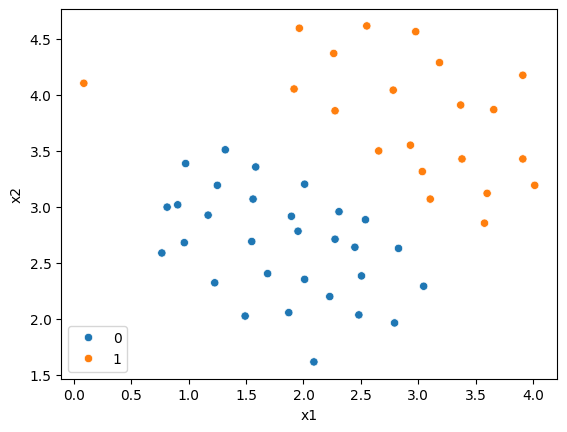

In [9]:
sns.scatterplot(df, x='x1', y='x2', hue="y")
plt.legend(loc="lower left")

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [10]:
from sklearn.svm import LinearSVC

svc_1 = LinearSVC(C=1, loss='hinge', max_iter=10000)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [11]:
X = df[['x1', 'x2']]
y = df['y']

svc_1.fit(X, y)
svc_1.score(X, y)

0.9803921568627451

It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [12]:
svc_2 = LinearSVC(C=1000, loss='hinge', max_iter=1000000)

X = df[['x1', 'x2']]
y = df['y']

svc_2.fit(X, y)
svc_2.score(X, y)

1.0

This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [13]:
conf_level = svc_1.decision_function(X)
conf_level

array([ 0.8027627 ,  0.38384035,  1.37740465,  0.52108803,  0.33331707,
        0.86860532,  0.68643522,  1.61111064,  0.83440156,  1.16705321,
        1.07315034,  0.22972551,  0.3317585 ,  0.79573479,  0.31572106,
        1.27400376,  1.21010019,  0.99988027,  0.56465745,  0.38981308,
       -0.43528541, -0.30886342, -0.68627118, -0.55403415, -0.33252441,
       -0.29385764, -0.44071911, -0.98399735, -0.68564256, -1.32848562,
       -1.00380044, -1.49231532, -0.61143393, -0.683459  , -1.00004969,
       -1.15275238, -1.57841887, -1.35599408, -1.03241112, -1.1850555 ,
       -0.77142756, -0.76694019, -0.46651845, -1.        , -0.51034727,
       -0.8586446 , -1.55903107, -0.25490711, -1.11366171, -1.54720329,
       -0.70996763])

<Axes: xlabel='x1', ylabel='x2'>

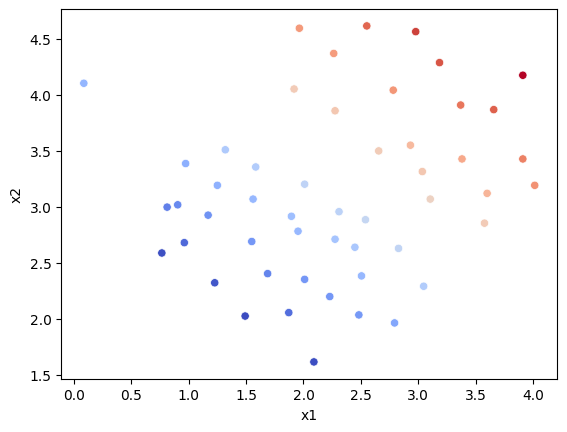

In [14]:
sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")

#### 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

In [15]:
conf_level = svc_2.decision_function(X)
conf_level

array([ 12.003719  ,   6.08410042,  15.14529176,   5.40158145,
         1.00006662,   5.67735013,   5.76051439,  14.62261941,
         9.5427113 ,  14.18605783,  10.27285193,   1.43481381,
         6.71603153,  10.88728373,   3.98223888,  13.2326563 ,
        10.86087816,   7.55392315,   3.59595409,   3.52500842,
        -0.99985432,  -1.01089373,  -5.17641908,  -4.7621374 ,
        -2.32003125,  -3.66460369,  -6.1199407 , -10.45136813,
        -7.08047902, -12.32485959,  -9.04763232, -11.98950109,
        -4.11186623,  -3.79006721,  -7.41159644,  -9.65556255,
       -13.90118043,  -9.49741493,  -6.47176423,  -7.00280871,
        -2.77682543,  -3.68059522,  -0.44513755,  -9.76026381,
        -4.85450468, -10.07695365, -15.74763111,  -2.21874017,
        -6.49583112, -11.03177728,   1.        ])

<Axes: xlabel='x1', ylabel='x2'>

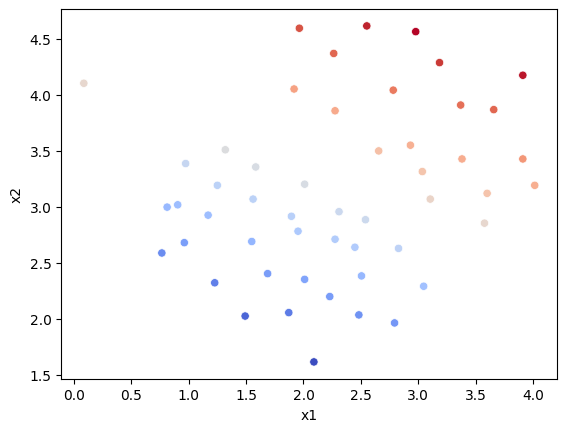

In [16]:
sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")

y = ax1 + bx2 + c

0 = ax1 + bx2 + c

x2 = -ax1/b - c/b

In [17]:
svc_2.coef_

array([[3.3844287 , 9.46277946]])

In [18]:
svc_2.intercept_

array([-38.13240984])

In [19]:
a = svc_2.coef_[0][0]
b = svc_2.coef_[0][1]
c = svc_2.intercept_

In [20]:
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

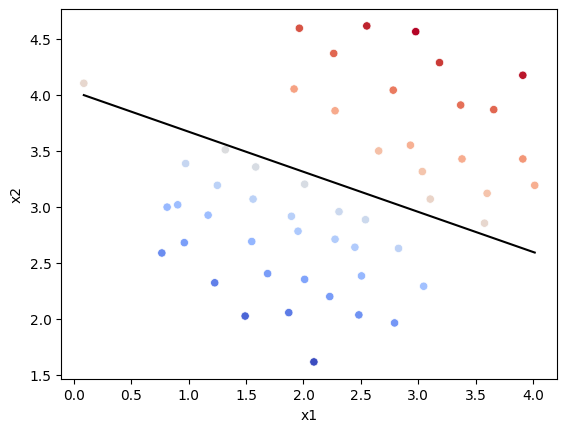

In [21]:
conf_level = svc_2.decision_function(X)
sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")
plt.plot(x_points, y_points, color="black")

In [22]:
a = svc_1.coef_[0][0]
b = svc_1.coef_[0][1]
c = svc_1.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

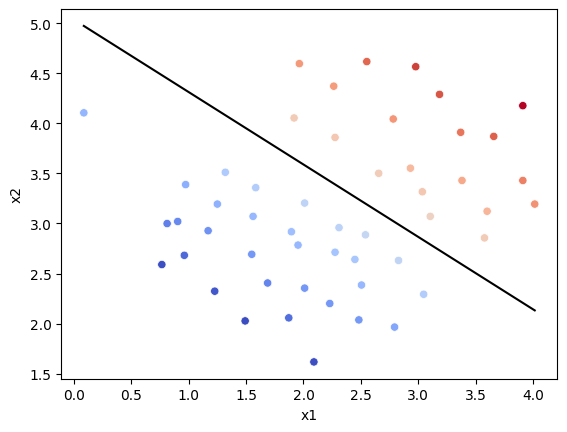

In [23]:
conf_level = svc_1.decision_function(X)
sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")
plt.plot(x_points, y_points, color="black")

Now we're going to move from a linear SVM to one that's capable of non-linear classification using kernels.  We're first tasked with implementing a gaussian kernel function.  Although scikit-learn has a gaussian kernel built in, for transparency we'll implement one from scratch.

## Exercise 2

That result matches the expected value from the exercise.  Next we're going to examine another data set, this time with a non-linear decision boundary.

#### 1. Load the data `ejer_1_data2.mat`

In [24]:
mat = sio.loadmat('data/ejer_1_data2.mat')
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 2. Create a DataFrame with the features and target

In [25]:
df = pd.DataFrame(mat['X'], columns=['x1','x2'])
df['y'] = mat['y']
df.head()

,x1,x2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      863 non-null    float64
 1   x2      863 non-null    float64
 2   y       863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [27]:
df.describe()

,x1,x2,y
count,863.000000,863.000000,863.000000
mean,0.503414,0.694304,0.556199
std,0.254967,0.158884,0.497120
min,0.044931,0.402632,0.000000
25%,0.292627,0.557018,0.000000
50%,0.512673,0.693713,1.000000
75%,0.699309,0.830409,1.000000
max,0.998848,0.988596,1.000000


#### 3. Plot a scatterplot with the data

<Axes: xlabel='x1', ylabel='x2'>

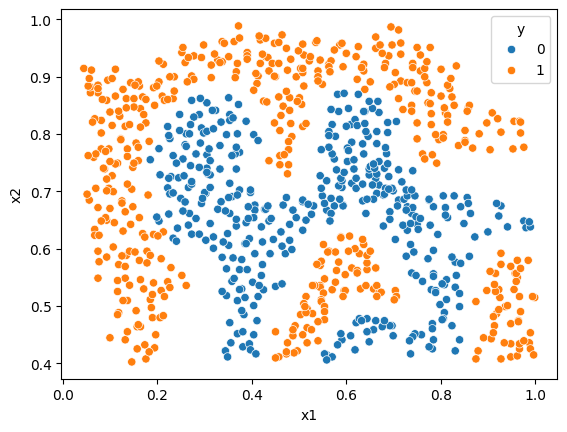

In [28]:
sns.scatterplot(df, x='x1', y='x2', hue="y")

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

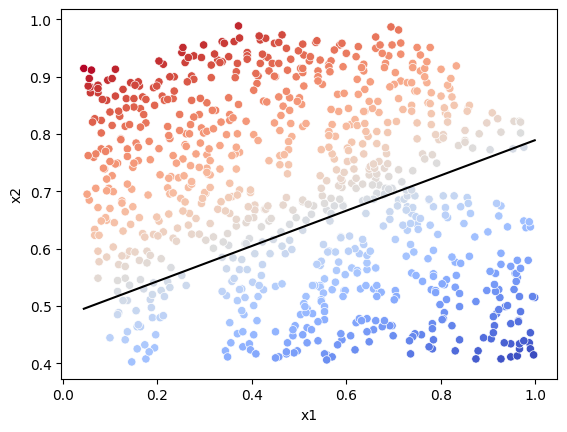

In [29]:
svc_3 = LinearSVC(C=1, loss="hinge", max_iter=10000)

X = df[['x1','x2']]
y = df['y']

svc_3.fit(X, y)
svc_3.score(X, y)

a = svc_3.coef_[0][0]
b = svc_3.coef_[0][1]
c = svc_3.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b
conf_level = svc_3.decision_function(X)
sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")
plt.plot(x_points, y_points, color="black")

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [30]:
from sklearn.svm import SVC

In [31]:
svc_4 = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [32]:
svc_4.fit(X, y)
svc_4.score(X, y)

0.9698725376593279

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [33]:
y_pred_proba = svc_4.predict_proba(X)
y_pred_proba

array([[3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       ...,
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00]], shape=(863, 2))

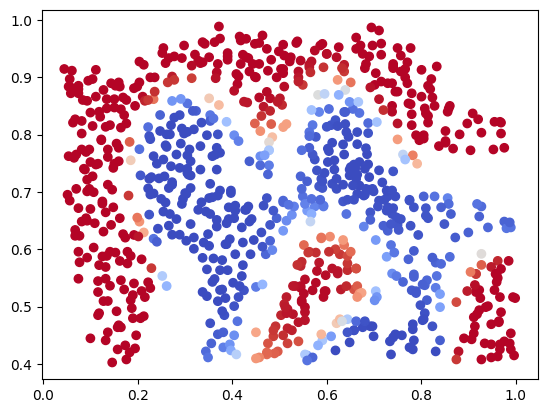

In [34]:
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

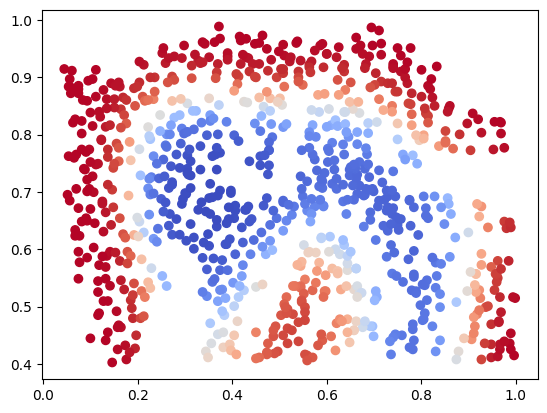

In [35]:
svc_5 = SVC(C=1, gamma=10, probability=True)
svc_5.fit(X, y)
svc_5.score(X, y)
y_pred_proba = svc_5.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

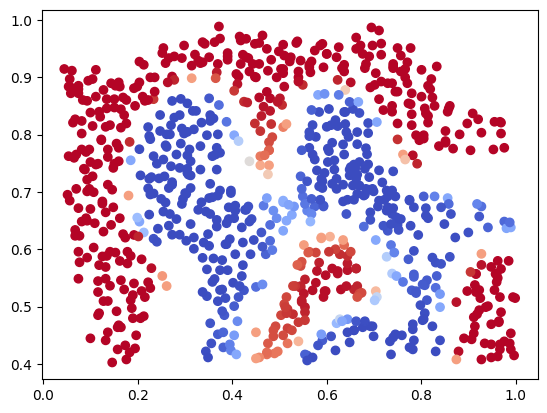

In [36]:
svc_6 = SVC(C=10000, gamma=10, probability=True)
svc_6.fit(X, y)
svc_6.score(X, y)
y_pred_proba = svc_6.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Axes: xlabel='x1', ylabel='x2'>

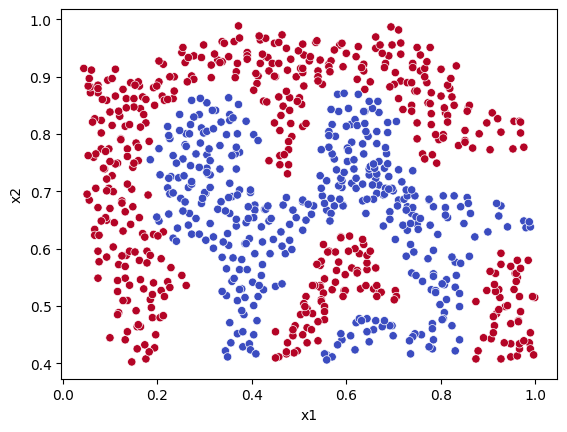

In [38]:
sns.scatterplot(df, x='x1', y='x2', c=df['y'], cmap="coolwarm")

<Axes: xlabel='x1', ylabel='x2'>

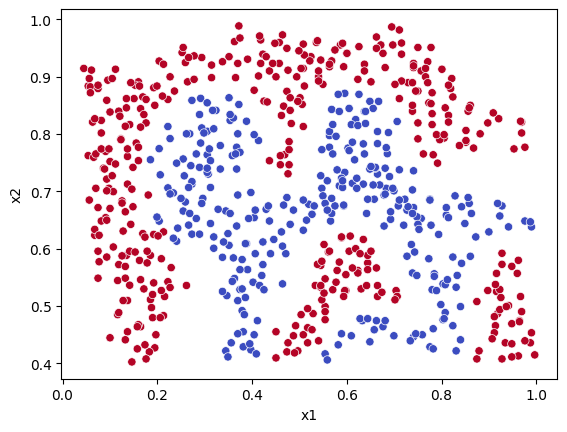

In [39]:
sns.scatterplot(X_train, x='x1', y='x2', c=y_train, cmap="coolwarm")

<Axes: xlabel='x1', ylabel='x2'>

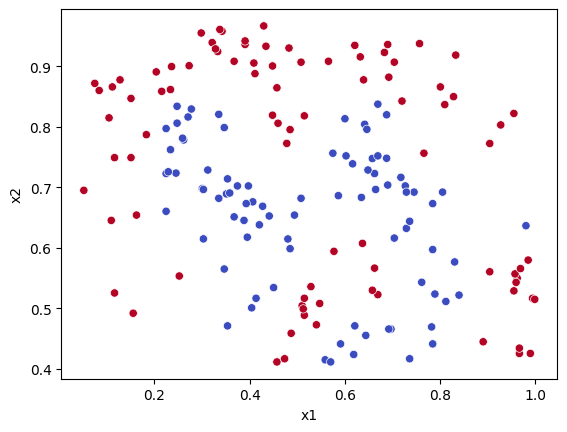

In [40]:
sns.scatterplot(X_test, x='x1', y='x2', c=y_test, cmap="coolwarm")

In [41]:
parameters = {
    "kernel": ['rbf', 'poly'],
    'C': [1,10,50,100]
}

gs = GridSearchCV(SVC(probability=True), parameters, cv=5, scoring='accuracy', verbose=2)
gs.fit(X_train, y_train)

print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.1s
[CV] END ...................................C=1, kernel=poly; total time=   0.1s
[CV] END ...................................C=1, kernel=poly; total time=   0.1s
[CV] END ...................................C=1, kernel=poly; total time=   0.1s
[CV] END ...................................C=1, kernel=poly; total time=   0.1s
[CV] END ...................................C=10, kernel=rbf; total time=   0.0s
[CV] END ...................................C=10,

In [42]:
final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

0.9421965317919075

In [43]:
import pickle

filename = "final_model.pkl"

with open(filename, "wb") as archivo_salida:
    pickle.dump(final_model, archivo_salida)

In [44]:
with open(filename, 'rb') as archivo_entrada:
    modelo_importado = pickle.load(archivo_entrada)

In [45]:
modelo_importado

SVC(C=100, probability=True)

In [46]:
modelo_importado.predict([[1,3]])

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1], dtype=uint8)

In [47]:
df_eval = pd.DataFrame(X_test, columns=['x1','x2'])
df_eval['y_pred'] = modelo_importado.predict_proba(X_test)[:,1]

<Axes: xlabel='x1', ylabel='x2'>

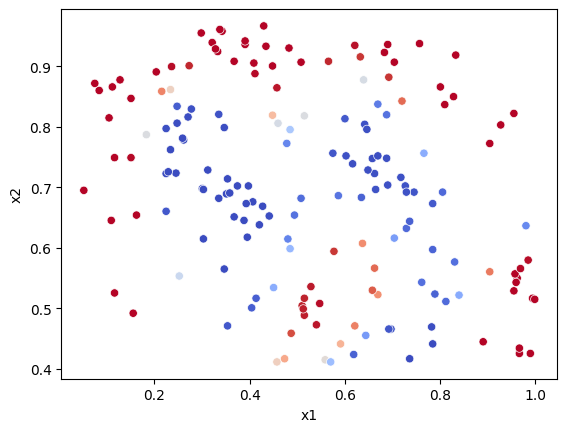

In [48]:
sns.scatterplot(df_eval, x='x1', y='x2', c=df_eval['y_pred'], cmap='coolwarm')

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline((
    ('polynomial', PolynomialFeatures()),
    ('classifier', LinearSVC(max_iter=100000))
))

params_svc = {'polynomial__degree': np.arange(2,6),
              'classifier__C': np.logspace(-1,2, 5)}

gs = GridSearchCV(pipe, params_svc, cv=5, scoring='accuracy', verbose=2)
gs.fit(X_train, y_train)

print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=2; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=3; total time=   0.0s
[CV] END ............classifier__C=0.1, polynomial__degree=4; total time=   0.0s
[CV] END ............classifier__C=0.1, polynom

0.8323699421965318

In [50]:
pipe = Pipeline((
    ('polynomial', PolynomialFeatures()),
    ('classifier', SVC(max_iter=100000))
))

params_svc = {'polynomial': [PolynomialFeatures(2), PolynomialFeatures(3), None],
            #   'polynomial__degree': np.arange(2,6),
            #   'classifier': [SVC(max_iter=100000)],
              'classifier__C': np.logspace(-1,2, 5),
              'classifier__kernel': ['linear', 'rbf']}

gs = GridSearchCV(pipe, params_svc, cv=5, scoring='accuracy', verbose=2)
gs.fit(X_train, y_train)

print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(degree=3); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(degree=3); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, polynomial=PolynomialFeatures(degree=3); total time=   0.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, pol

0.9248554913294798